In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

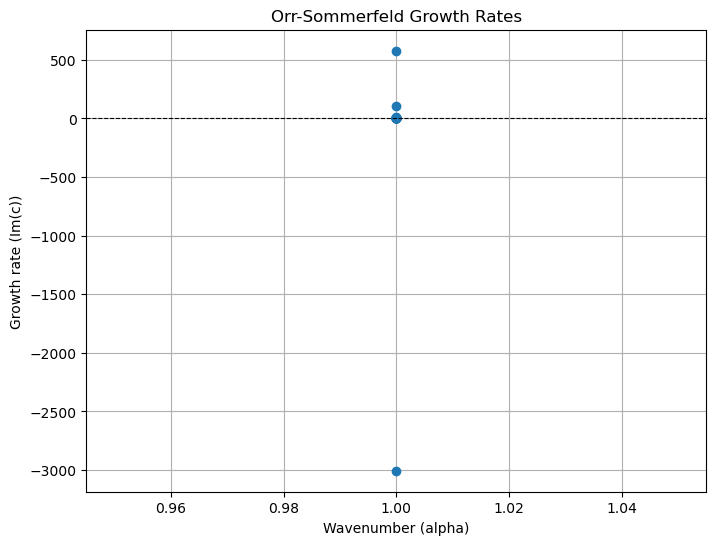

In [2]:
# Chebyshev differentiation matrix
def chebyshev(N):
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.array([2] + [1] * (N - 1) + [2]) * (-1) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1))
    dX = X - X.T
    D = (c[:, None] / c[None, :]) / (dX + np.eye(N + 1))
    D -= np.diag(D.sum(axis=1))
    return D, x

# Orr-Sommerfeld operator
def orr_sommerfeld(U, U_prime, U_double_prime, alpha, Re, N):
    D, y = chebyshev(N)
    D2 = np.dot(D, D)
    D4 = np.dot(D2, D2)

    I = np.eye(N + 1)
    A = (1j * alpha * (np.diag(U) @ (D2 - alpha**2 * I) - np.diag(U_double_prime))) / Re
    B = (D2 - alpha**2 * I) @ (D2 - alpha**2 * I)

    A += 1j * alpha * np.eye(N + 1)
    B /= Re

    # Boundary conditions
    for i in [0, -1]:
        A[i, :] = 0
        B[i, :] = 0
        A[i, i] = 1
        B[i, i] = 0

    return A, B, y

# Base flow (Error function)
def base_flow(y):
    U = np.tanh(2 * y)  # Approximation of error function
    U_prime = 2 * (1 - np.tanh(2 * y)**2)
    U_double_prime = -4 * np.tanh(2 * y) * (1 - np.tanh(2 * y)**2)
    return U, U_prime, U_double_prime

# Parameters
N = 50  # Number of Chebyshev points
alpha = 1.0  # Wavenumber
Re = 1000  # Reynolds number

# Generate base flow and Orr-Sommerfeld matrices
U, U_prime, U_double_prime = base_flow(np.linspace(-1, 1, N + 1))
A, B, y = orr_sommerfeld(U, U_prime, U_double_prime, alpha, Re, N)

# Solve the eigenvalue problem
eigenvalues, eigenvectors = la.eig(A, B)

# Extract growth rates
growth_rates = eigenvalues.imag

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(alpha * np.ones_like(growth_rates), growth_rates, 'o')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Wavenumber (alpha)')
plt.ylabel('Growth rate (Im(c))')
plt.title('Orr-Sommerfeld Growth Rates')
plt.grid()
plt.show()